data cleanup is success! Neural Network Model is Training ...

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 670ms/step - accuracy: 0.4717 - loss: 1.0804 - val_accuracy: 0.5000 - val_loss: 1.0777
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 337ms/step - accuracy: 0.6792 - loss: 1.0470 - val_accuracy: 0.5714 - val_loss: 1.0540
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6981 - loss: 1.0166 - val_accuracy: 0.6429 - val_loss: 1.0310
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6792 - loss: 0.9875 - val_accuracy: 0.6429 - val_loss: 1.0075
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6792 - loss: 0.9578 - val_accuracy: 0.6429 - val_loss: 0.9844
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6792 - loss: 0.9261 - val_accuracy: 0.6429 - val_loss: 0.9620
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.6792 - loss: 0.8896 - val_accuracy: 0.6429 - val_loss: 0.9407
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6792 - loss: 0.8536 - val_accuracy: 0.6429 - val_loss: 0.9197
Epoch 9/

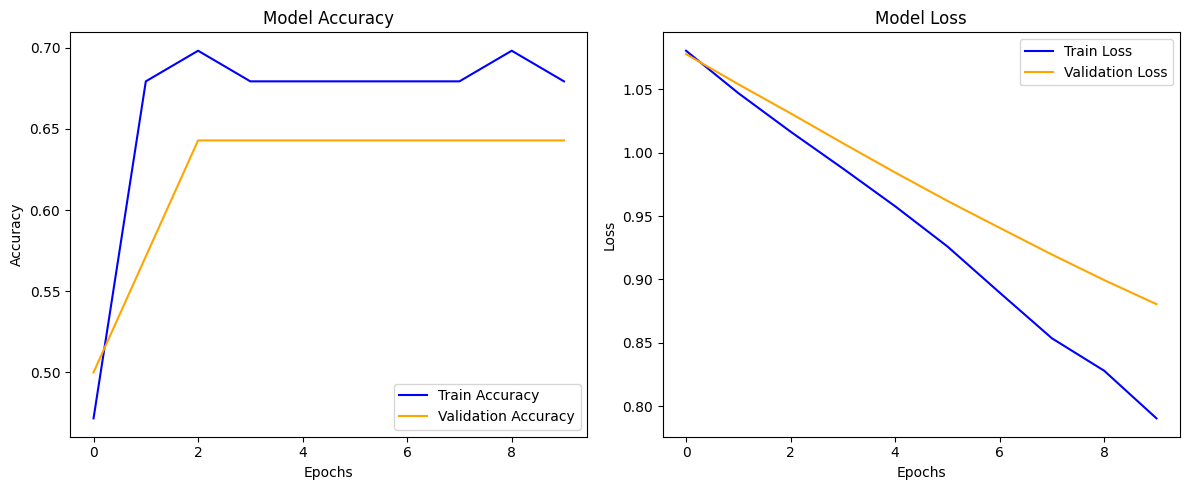

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6429 - loss: 0.8805

--- Test Accuracy : 64.29% ---


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


df = pd.read_csv('/content/3) Sentiment dataset.csv')
df = df.dropna(subset=['Text', 'Sentiment'])


df['Sentiment'] = df['Sentiment'].astype(str).str.strip().str.capitalize()


valid_sentiments = ['Positive', 'Negative', 'Neutral']
df = df[df['Sentiment'].isin(valid_sentiments)]
# --------------------------------------------------------

X_text = df['Text']
y_label = df['Sentiment']

vectorizer = TfidfVectorizer(max_features=2000)
X = vectorizer.fit_transform(X_text).toarray()

encoder = LabelEncoder()
y = encoder.fit_transform(y_label)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("data cleanup is success! Neural Network Model is Training ...\n")


history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\n--- Test Accuracy : {accuracy * 100:.2f}% ---")

In [4]:
import pandas as pd


sentiment_df = pd.read_csv('/content/3) Sentiment dataset.csv')


sentiment_df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


Data ready! now model is training... 

--- Random Forest Model Evaluation ---
Accuracy: 0.9565217391304348
Precision: 0.9583333333333334
Recall: 0.7263157894736842
F1-Score: 0.8263473053892215


/tmp/ipykernel_7484/1121677138.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')


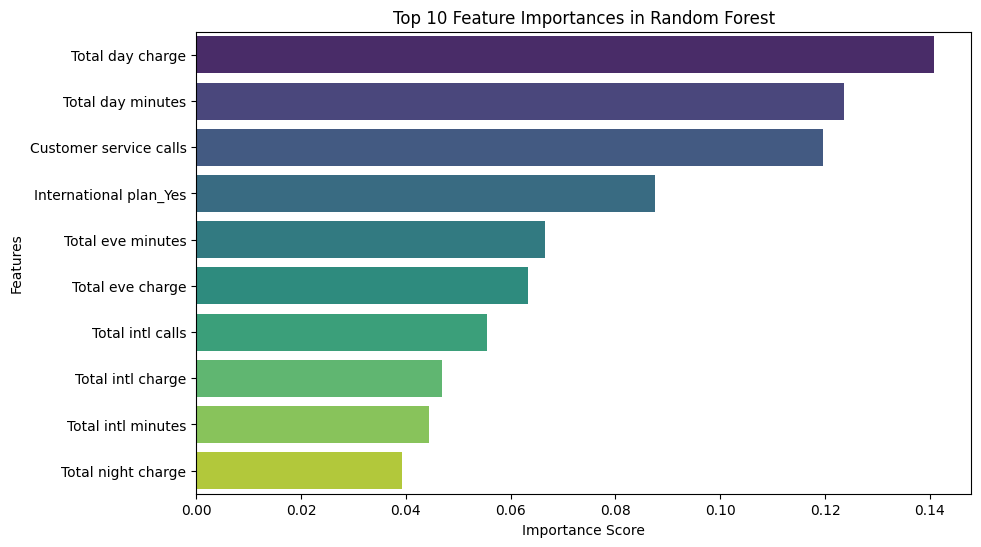

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


train_df = pd.read_csv('/content/churn-bigml-80.csv')
test_df = pd.read_csv('/content/churn-bigml-20.csv')

train_df = train_df.drop('State', axis=1)
test_df = test_df.drop('State', axis=1)

train_df['Churn'] = train_df['Churn'].astype(int)
test_df['Churn'] = test_df['Churn'].astype(int)

X_train = train_df.drop('Churn', axis=1)
y_train = train_df['Churn']
X_test = test_df.drop('Churn', axis=1)
y_test = test_df['Churn']

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data ready! now model is training... ")


param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_rf_model = grid_search.best_estimator_

# 3. Anawaki kima saha Evaluate kirima
y_pred_rf = best_rf_model.predict(X_test_scaled)

print("\n--- Random Forest Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))


importances = best_rf_model.feature_importances_
feature_names = X_train.columns

feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')
plt.title("Top 10 Feature Importances in Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Hyperparameter Tuning sadaha parameters sakasima
param_grid = {
    'n_estimators': [50, 100, 200], # Gas kiyak hadanawada (number of trees)
    'max_depth': [None, 10, 20],    # Gahe uparima gabura (maximum depth)
}

# 2. Random Forest Model eka saha GridSearchCV (Cross-validation sadaha) saadima
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

print("Model eka train wenawa... (Mekata thappara kihipayak yai)")
grid_search.fit(X_train_scaled, y_train)

# 3. Hondama Model eka thoraganima
best_rf_model = grid_search.best_estimator_
print("\nHondama Parameters:", grid_search.best_params_)

# 4. Anawaki kima saha Evaluate kirima
y_pred_rf = best_rf_model.predict(X_test_scaled)

print("\n--- Random Forest Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))

# 5. Feature Importance Analysis (Wadiyenma balapana karunu)
importances = best_rf_model.feature_importances_
feature_names = X_train.columns

feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Eya prastharayakin (Graph) penweema
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')
plt.title("Top 10 Feature Importances in Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

Model eka train wenawa... (Mekata thappara kihipayak yai)


NameError: name 'X_train_scaled' is not defined